<a href="https://colab.research.google.com/github/jrangelg/Artificial-intelligence/blob/main/Riesgo_en_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gestión Integral de Riesgos Financieros en un Banco

## 1. Valor en Riesgo (VaR)

El **Valor en Riesgo (VaR)** mide la pérdida máxima esperada de un portafolio en un horizonte de tiempo determinado y con un nivel de confianza $\alpha$.

$$
VaR_{\alpha} = - \inf \left\{ x \in \mathbb{R} : P(R_p \leq x) \geq 1-\alpha \right\}
$$

Bajo supuesto de normalidad:

$$
VaR_{\alpha} = -\left( \mu_p + z_{\alpha}\sigma_p \right)
$$

donde:

- $\mu_p$ = rendimiento esperado  
- $\sigma_p$ = volatilidad  
- $z_{\alpha}$ = cuantil normal estándar  

---

## 2. Expected Shortfall (ES)

El Expected Shortfall mide la pérdida promedio condicionada a superar el VaR:

$$
ES_{\alpha} = - \mathbb{E}[R_p \mid R_p \leq -VaR_{\alpha}]
$$

Es una medida coherente de riesgo y captura mejor eventos extremos.

---

## 3. Riesgo de Mercado

La varianza del portafolio se calcula como:

$$
\sigma_p^2 = w' \Sigma w
$$

El rendimiento esperado es:

$$
\mu_p = w' \mu
$$

donde:

- $w$ = vector de ponderaciones  
- $\Sigma$ = matriz de covarianza  

---

## 4. Riesgo de Crédito

La pérdida esperada se define como:

$$
EL = EAD \times PD \times LGD
$$

donde:

- $EAD$ = exposición al incumplimiento  
- $PD$ = probabilidad de default  
- $LGD$ = pérdida dado el default  

---

## 5. Riesgo de Liquidez

$$
\text{Ratio de Liquidez} = \frac{\text{Activos Líquidos}}{\text{Salidas Esperadas}}
$$

---

## 6. Riesgo de Concentración

$$
HHI = \sum_{i=1}^{n} s_i^2
$$

donde $s_i$ es la proporción de exposición por contraparte.

---

## 7. Riesgo de Solvencia

$$
\text{Ratio de Solvencia} = \frac{\text{Patrimonio Técnico}}{\text{Activos Ponderados por Riesgo}}
$$

Garantiza que la entidad tenga respaldo financiero suficiente.

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
mi_arreglo=np.array([1,2,3,4,5])
print(mi_arreglo)

[1 2 3 4 5]


In [35]:
mi_arreglo.mean()

np.float64(3.0)

In [36]:
media=mi_arreglo.mean()
desviacion_estandar=mi_arreglo.std()

In [37]:
from scipy import stats

stats.norm.ppf(0.05)

np.float64(-1.6448536269514729)

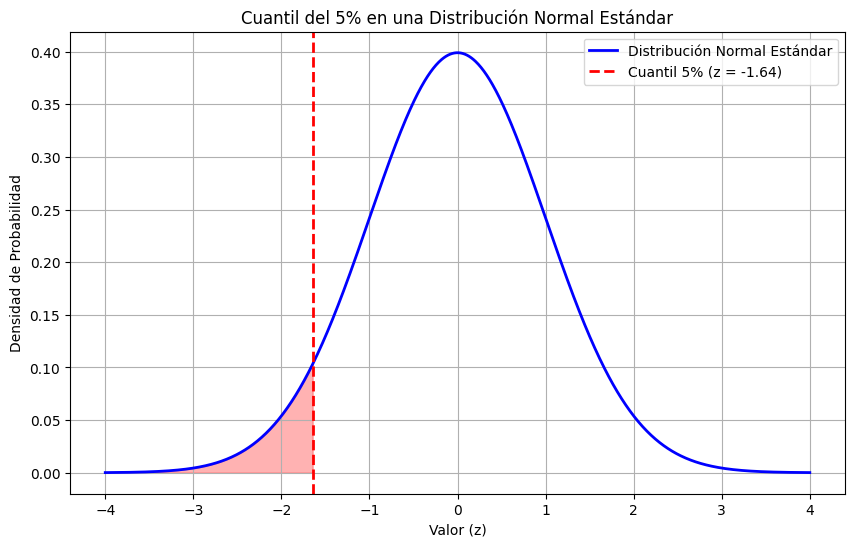

In [38]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Cuantil previamente calculado
z_alpha = stats.norm.ppf(0.05)

# Rango de valores para la distribución normal estándar
x = np.linspace(-4, 4, 1000)
y = norm.pdf(x) # Función de densidad de probabilidad

plt.figure(figsize=(10, 6))
plt.plot(x, y, color='blue', lw=2, label='Distribución Normal Estándar')

# Marcar el cuantil
plt.axvline(z_alpha, color='red', linestyle='--', lw=2, label=f'Cuantil 5% (z = {z_alpha:.2f})')

# Rellenar el área a la izquierda del cuantil
x_fill = np.linspace(-4, z_alpha, 1000)
y_fill = norm.pdf(x_fill)
plt.fill_between(x_fill, 0, y_fill, color='red', alpha=0.3)

plt.title('Cuantil del 5% en una Distribución Normal Estándar')
plt.xlabel('Valor (z)')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(True)
plt.show()

In [39]:
var_a = media + 1.645 * desviacion_estandar
print(var_a)

5.326381310103741


In [40]:
# Llenar un objeto con los nuemros de 1 al 10
a = np.array([])
for i in range(1, 11):
    a = np.append(a, i)
print(a)

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]


In [41]:
# Matriz de varianzas y covarianzas

np.array([[1,1,1,1],[1,2,2,2],[1,2,3,3],[1,2,3,4]])

array([[1, 1, 1, 1],
       [1, 2, 2, 2],
       [1, 2, 3, 3],
       [1, 2, 3, 4]])

In [42]:
# Multiplicar matrices en Py

uno = np.array([1,1,1,1])
# w'Sigma w
S = np.array([[1,1,1,1],[1,2,2,2],[1,2,3,3],[1,2,3,4]])
uno @ S
uno @ S @ np.matrix.transpose(uno)


np.int64(30)

In [43]:
def cuadrado (a):
    return a**2
cuadrado(2)

4

In [44]:
def var_ries(x = np.array([1,2,3,4,5])):
    return x.mean() + 1.645 * x.std()
var_ries()

np.float64(5.326381310103741)

In [45]:
def var_gamma(x = np.array([1,2,3,4,5])):
    return np.quantile(x, 0.05)
var_gamma()

np.float64(1.2)

(array([ 1., 11.,  9., 10., 23., 26., 26., 25., 26., 32., 26., 21., 30.,
        28., 28., 21., 21., 30., 28., 30., 27., 24., 24., 20., 22., 30.,
        15., 17., 20., 17., 12., 18., 16., 19., 13., 15., 14., 16., 13.,
        22., 11.,  6., 11.,  5.,  4., 10.,  5.,  4.,  5.,  5.,  6.,  4.,
         1.,  6., 12.,  2.,  5.,  6.,  6.,  4.,  6.,  3.,  1.,  1.,  3.,
         3.,  2.,  2.,  6.,  1.,  2.,  1.,  1.,  0.,  2.,  0.,  0.,  0.,
         0.,  4.,  2.,  1.,  0.,  0.,  2.,  0.,  3.,  0.,  0.,  1.,  2.,
         0.,  2.,  0.,  1.,  2.,  0.,  0.,  1.,  1.]),
 array([ 0.08537333,  0.30650699,  0.52764066,  0.74877432,  0.96990798,
         1.19104164,  1.4121753 ,  1.63330897,  1.85444263,  2.07557629,
         2.29670995,  2.51784361,  2.73897727,  2.96011094,  3.1812446 ,
         3.40237826,  3.62351192,  3.84464558,  4.06577925,  4.28691291,
         4.50804657,  4.72918023,  4.95031389,  5.17144756,  5.39258122,
         5.61371488,  5.83484854,  6.0559822 ,  6.27711587,  6.498249

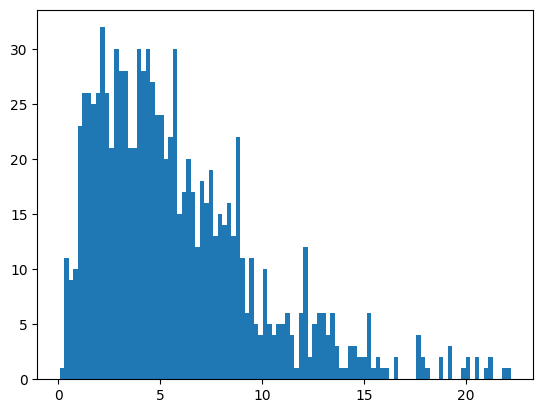

In [46]:
y = np.random.gamma(2,3,1000)
plt.hist(y, bins = 100)

In [47]:
var_gamma(y)

np.float64(1.132690025553781)

In [48]:
import numpy as np

# ==============================
# SIMULACIÓN BÁSICA DE RIESGO FINANCIERO PARA UN BANCO
# ==============================

np.random.seed(123)

# ------------------------------
# 1. SIMULACIÓN DE PORTAFOLIO
# ------------------------------

n_activos = 5
n_dias = 1000
nivel_confianza = 0.99

# Supuestos de medias y volatilidades diarias
medias = np.array([0.0005, 0.0003, 0.0004, 0.0002, 0.0006])
volatilidades = np.array([0.01, 0.012, 0.009, 0.011, 0.013])

# Matriz de correlación simple
correlacion = 0.3
cov = np.diag(volatilidades) @ (np.full((n_activos, n_activos), correlacion) +
       np.diag(np.ones(n_activos)*(1-correlacion))) @ np.diag(volatilidades)

# Simulación de rendimientos
rendimientos = np.random.multivariate_normal(medias, cov, n_dias)

# Pesos del portafolio
pesos = np.array([0.2, 0.25, 0.15, 0.2, 0.2])

# Retorno del portafolio
ret_port = rendimientos @ pesos

# ------------------------------
# 2. VALOR EN RIESGO (VaR)
# ------------------------------

VaR = -np.percentile(ret_port, (1 - nivel_confianza) * 100)

# Expected Shortfall (CVaR)
perdidas_extremas = ret_port[ret_port <= -VaR]
ES = -np.mean(perdidas_extremas)

# Sharpe Ratio
rf = 0.0001  # tasa libre de riesgo diaria
sharpe = (np.mean(ret_port) - rf) / np.std(ret_port)

# ------------------------------
# 3. RIESGO DE CRÉDITO (Modelo simple)
# ------------------------------

exposicion = 10000000  # 10 millones
prob_default = 0.02
loss_given_default = 0.45

perdida_esperada_credito = exposicion * prob_default * loss_given_default

# ------------------------------
# 4. RIESGO DE LIQUIDEZ (Indicador simple)
# ------------------------------

activos_liquidos = 50000000
salidas_esperadas = 40000000

ratio_liquidez = activos_liquidos / salidas_esperadas

# ------------------------------
# 5. RIESGO DE CONCENTRACIÓN
# ------------------------------

exposiciones_contraparte = np.array([20, 15, 25, 30, 10])  # %
indice_herfindahl = np.sum((exposiciones_contraparte / 100) ** 2)

# ------------------------------
# 6. SOLVENCIA (Capital Adecuado)
# ------------------------------

activos_ponderados_riesgo = 80000000
patrimonio_tecnico = 12000000

ratio_solvencia = patrimonio_tecnico / activos_ponderados_riesgo

# ------------------------------
# RESULTADOS
# ------------------------------

print("===== RIESGO DE MERCADO =====")
print("VaR 99%:", round(VaR, 6))
print("Expected Shortfall:", round(ES, 6))
print("Sharpe Ratio:", round(sharpe, 4))

print("\n===== RIESGO DE CRÉDITO =====")
print("Pérdida Esperada Crédito:", round(perdida_esperada_credito, 2))

print("\n===== RIESGO DE LIQUIDEZ =====")
print("Ratio de Liquidez:", round(ratio_liquidez, 2))

print("\n===== RIESGO DE CONCENTRACIÓN =====")
print("Índice Herfindahl:", round(indice_herfindahl, 4))

print("\n===== SOLVENCIA =====")
print("Ratio de Solvencia:", round(ratio_solvencia, 4))

===== RIESGO DE MERCADO =====
VaR 99%: 0.017938
Expected Shortfall: 0.019509
Sharpe Ratio: -0.002

===== RIESGO DE CRÉDITO =====
Pérdida Esperada Crédito: 90000.0

===== RIESGO DE LIQUIDEZ =====
Ratio de Liquidez: 1.25

===== RIESGO DE CONCENTRACIÓN =====
Índice Herfindahl: 0.225

===== SOLVENCIA =====
Ratio de Solvencia: 0.15


# Conceptos Técnicos en Seguros y Reaseguros

## 1. Prima de Seguro

La **prima** es el precio que paga el asegurado por transferir el riesgo a la aseguradora.

### Prima Pura o Prima de Riesgo

Representa el valor esperado de la pérdida:

$$
\text{Prima Pura} = \mathbb{E}[L]
$$

Si la frecuencia es $\lambda$ y la severidad media es $\mu_L$:

$$
\text{Prima Pura} = \lambda \mu_L
$$

### Prima Comercial

Incluye gastos administrativos, carga de seguridad y utilidad:

$$
\text{Prima Comercial} = \text{Prima Pura} + \text{Gastos} + \text{Margen de Seguridad}
$$

---

## 2. Deducible

El **deducible** es la parte de la pérdida que asume el asegurado.

Si la pérdida es $L$ y el deducible es $d$:

$$
\text{Pago Aseguradora} = \max(0, L - d)
$$

El deducible reduce la prima porque disminuye la pérdida esperada.

---

## 3. Límite de Cobertura

El **límite** es el monto máximo que pagará la aseguradora.

Si el límite es $u$:

$$
\text{Pago} = \min(u, L)
$$

Con deducible y límite simultáneo:

$$
\text{Pago} = \min\left(u, \max(0, L - d)\right)
$$

---

## 4. Ajustes y Reservas

### Reserva Matemática o Técnica

Corresponde al valor presente de obligaciones futuras:

$$
\text{Reserva} = \mathbb{E}[L \mid \text{Información Disponible}]
$$

### Ajuste por Inflación o Tendencia

Si la inflación esperada es $i$:

$$
L_{ajustado} = L (1+i)^t
$$

---

## 5. Reaseguro

El **reaseguro** es el mecanismo mediante el cual una aseguradora transfiere parte del riesgo a otra entidad.

### Reaseguro Proporcional

El reasegurador asume una proporción $\alpha$ de la pérdida:

$$
\text{Pérdida Reasegurador} = \alpha L
$$

$$
\text{Pérdida Aseguradora} = (1-\alpha)L
$$

---

### Reaseguro No Proporcional (Exceso de Pérdida)

Si la prioridad es $d$ y el límite es $u$:

$$
\text{Pago Reaseguro} = \min\left(u, \max(0, L - d)\right)
$$

La aseguradora retiene:

$$
\text{Retención} = L - \text{Pago Reaseguro}
$$

---

## 6. Valor Esperado con Deducible

Si $L$ es variable aleatoria con función de distribución $F_L$:

$$
\mathbb{E}[(L-d)^+] = \int_d^{\infty} (x-d) f_L(x) dx
$$

donde $(L-d)^+ = \max(0, L-d)$.

---

## 7. Principio de Equivalencia Actuarial

La prima debe cubrir el valor esperado de las pérdidas:

$$
\mathbb{E}[\text{Prima}] = \mathbb{E}[\text{Indemnización}]
$$

---

## 8. Margen de Solvencia

Para garantizar estabilidad financiera:

$$
\text{Capital Requerido} \geq VaR_{\alpha}(L)
$$

Esto asegura que la entidad pueda cubrir pérdidas extremas con alta probabilidad.

In [49]:
import numpy as np

np.random.seed(42)

# ===============================
# MODELO BÁSICO DE SEGUROS Y REASEGUROS
# ===============================

# 1. MODELO FRECUENCIA - SEVERIDAD
n_sim = 100000

lambda_freq = 2.5              # frecuencia esperada (Poisson)
media_severidad = 10000        # severidad promedio
desv_severidad = 5000          # desviación severidad

# Simulación número de siniestros
N = np.random.poisson(lambda_freq, n_sim)

# Simulación severidades (normal truncada en 0)
severidades = np.maximum(
    0,
    np.random.normal(media_severidad, desv_severidad, (n_sim, np.max(N)))
)

# Construcción pérdidas agregadas
S = np.array([np.sum(severidades[i, :N[i]]) for i in range(n_sim)])

# ===============================
# 2. DEDUCIBLE Y LÍMITE
# ===============================

deducible = 5000
limite = 20000

indemnizacion = np.minimum(
    limite,
    np.maximum(0, S - deducible)
)

prima_pura = np.mean(indemnizacion)

# ===============================
# 3. REASEGURO PROPORCIONAL
# ===============================

alpha = 0.4  # porcentaje cedido

perdida_reaseguro_prop = alpha * indemnizacion
perdida_aseguradora_prop = (1 - alpha) * indemnizacion

# ===============================
# 4. REASEGURO EXCESO DE PÉRDIDA
# ===============================

prioridad = 15000
limite_reaseguro = 30000

pago_reaseguro_xl = np.minimum(
    limite_reaseguro,
    np.maximum(0, indemnizacion - prioridad)
)

retencion_aseguradora_xl = indemnizacion - pago_reaseguro_xl

# ===============================
# 5. VaR Y EXPECTED SHORTFALL
# ===============================

nivel_confianza = 0.99

VaR = np.percentile(indemnizacion, nivel_confianza * 100)
ES = np.mean(indemnizacion[indemnizacion >= VaR])

# ===============================
# RESULTADOS
# ===============================

print("===== PRIMA PURA =====")
print("Prima pura estimada:", round(prima_pura, 2))

print("\n===== REASEGURO PROPORCIONAL =====")
print("Pérdida media reasegurador:", round(np.mean(perdida_reaseguro_prop), 2))
print("Pérdida media aseguradora:", round(np.mean(perdida_aseguradora_prop), 2))

print("\n===== REASEGURO EXCESO DE PÉRDIDA =====")
print("Pago medio reaseguro XL:", round(np.mean(pago_reaseguro_xl), 2))
print("Retención media aseguradora:", round(np.mean(retencion_aseguradora_xl), 2))

print("\n===== RIESGO =====")
print("VaR 99%:", round(VaR, 2))
print("Expected Shortfall:", round(ES, 2))

===== PRIMA PURA =====
Prima pura estimada: 13537.14

===== REASEGURO PROPORCIONAL =====
Pérdida media reasegurador: 5414.85
Pérdida media aseguradora: 8122.28

===== REASEGURO EXCESO DE PÉRDIDA =====
Pago medio reaseguro XL: 2531.92
Retención media aseguradora: 11005.21

===== RIESGO =====
VaR 99%: 20000.0
Expected Shortfall: 20000.0


In [50]:
import numpy as np

np.random.seed(42)

# ==========================================
# MODELO ACTUARIAL CON SOPORTE REAL POSITIVO
# (Frecuencia Poisson + Severidad Lognormal)
# ==========================================

n_sim = 100000

# 1. FRECUENCIA
lambda_freq = 2.5
N = np.random.poisson(lambda_freq, n_sim)

# 2. SEVERIDAD (LOGNORMAL > 0)
mu_logn = 9.0        # parámetro log-media
sigma_logn = 0.8     # parámetro log-desviación

max_siniestros = np.max(N)
severidades = np.random.lognormal(mu_logn, sigma_logn, (n_sim, max_siniestros))

# 3. PÉRDIDA AGREGADA
S = np.array([np.sum(severidades[i, :N[i]]) for i in range(n_sim)])

# ==========================================
# DEDUCIBLE Y LÍMITE
# ==========================================

deducible = 10000
limite = 100000

indemnizacion = np.minimum(
    limite,
    np.maximum(0, S - deducible)
)

prima_pura = np.mean(indemnizacion)

# ==========================================
# REASEGURO EXCESO DE PÉRDIDA (XL)
# ==========================================

prioridad = 50000
limite_reaseguro = 150000

pago_reaseguro = np.minimum(
    limite_reaseguro,
    np.maximum(0, indemnizacion - prioridad)
)

retencion_aseguradora = indemnizacion - pago_reaseguro

# ==========================================
# MEDIDAS DE RIESGO
# ==========================================

nivel_confianza = 0.99

VaR = np.percentile(indemnizacion, nivel_confianza * 100)
ES = np.mean(indemnizacion[indemnizacion >= VaR])

# ==========================================
# RESULTADOS
# ==========================================

print("===== MODELO CON LOGNORMAL (SOPORTE POSITIVO) =====")
print("Prima pura:", round(prima_pura, 2))

print("\n===== REASEGURO XL =====")
print("Pago medio reaseguro:", round(np.mean(pago_reaseguro), 2))
print("Retención media aseguradora:", round(np.mean(retencion_aseguradora), 2))

print("\n===== MEDIDAS DE RIESGO =====")
print("VaR 99%:", round(VaR, 2))
print("Expected Shortfall 99%:", round(ES, 2))

===== MODELO CON LOGNORMAL (SOPORTE POSITIVO) =====
Prima pura: 19100.08

===== REASEGURO XL =====
Pago medio reaseguro: 1850.83
Retención media aseguradora: 17249.25

===== MEDIDAS DE RIESGO =====
VaR 99%: 97844.12
Expected Shortfall 99%: 99909.35


# Fundamentos de Python

## 1. ¿Qué es Python?

Python es un lenguaje de programación interpretado, de alto nivel y multiparadigma.  
Permite programación:

- Procedimental
- Orientada a objetos
- Funcional

Es ampliamente usado en ciencia de datos, inteligencia artificial, finanzas y desarrollo web.

---

## 2. Variables y Tipos de Datos

En Python no es necesario declarar el tipo de variable explícitamente.

```python
x = 10              # entero (int)
y = 3.14            # flotante (float)
nombre = "Juan"     # cadena (str)
activo = True       # booleano (bool)
```

Python es de tipado dinámico.

---

## 3. Operadores Básicos

### Operadores aritméticos

```python
a + b
a - b
a * b
a / b
a ** b   # potencia
a % b    # módulo
```

### Operadores lógicos

```python
and
or
not
```

---

## 4. Estructuras de Control

### Condicional

```python
if x > 0:
    print("Positivo")
elif x == 0:
    print("Cero")
else:
    print("Negativo")
```

### Ciclo for

```python
for i in range(5):
    print(i)
```

### Ciclo while

```python
while x > 0:
    x -= 1
```

---

## 5. Estructuras de Datos

### Listas

```python
lista = [1, 2, 3, 4]
lista.append(5)
```

### Tuplas

```python
tupla = (1, 2, 3)
```

### Diccionarios

```python
dic = {"a": 1, "b": 2}
```

### Conjuntos

```python
conjunto = {1, 2, 3}
```

---

## 6. Funciones

```python
def suma(a, b):
    return a + b

resultado = suma(3, 4)
```

Las funciones pueden tener parámetros por defecto:

```python
def potencia(x, n=2):
    return x ** n
```

---

## 7. Programación Orientada a Objetos

```python
class Persona:
    def __init__(self, nombre):
        self.nombre = nombre

    def saludar(self):
        return "Hola " + self.nombre
```

---

## 8. Librerías

Se importan usando:

```python
import math
import numpy as np
```

Ejemplo:

```python
math.sqrt(16)
np.mean([1,2,3])
```

---

## 9. Manejo de Excepciones

```python
try:
    x = 10 / 0
except ZeroDivisionError:
    print("Error: división por cero")
```

---

## 10. Buenas Prácticas

- Usar nombres descriptivos
- Seguir PEP8
- Documentar funciones
- Modularizar el código

---

Python es un lenguaje versátil y fundamental para áreas como:

- Ciencia de datos
- Finanzas cuantitativas
- Actuaría
- Machine Learning
- Automatización

In [51]:
# ==========================
# Ejemplos básicos con for
# ==========================

# 1. Recorrer una lista
numeros = [10, 20, 30, 40, 50]

for n in numeros:
    print("Número:", n)


# 2. Usar range()
for i in range(5):
    print("Iteración:", i)


# 3. Sumar elementos de una lista
suma = 0
for n in numeros:
    suma += n

print("Suma total:", suma)


# 4. Calcular cuadrados
for i in range(1, 6):
    print("Cuadrado de", i, "=", i**2)


# 5. Ejemplo aplicado a riesgo (simulación simple)
import numpy as np

np.random.seed(42)
n_sim = 5

for i in range(n_sim):
    perdida = np.random.lognormal(mean=8, sigma=0.5)
    print("Simulación", i+1, "Pérdida:", round(perdida, 2))

Número: 10
Número: 20
Número: 30
Número: 40
Número: 50
Iteración: 0
Iteración: 1
Iteración: 2
Iteración: 3
Iteración: 4
Suma total: 150
Cuadrado de 1 = 1
Cuadrado de 2 = 4
Cuadrado de 3 = 9
Cuadrado de 4 = 16
Cuadrado de 5 = 25
Simulación 1 Pérdida: 3821.34
Simulación 2 Pérdida: 2781.84
Simulación 3 Pérdida: 4120.97
Simulación 4 Pérdida: 6383.78
Simulación 5 Pérdida: 2651.61


In [52]:
import numpy as np
from scipy import stats

np.random.seed(123)

# ==========================================
# COMPARACIÓN DE AJUSTES:
# Gamma vs Normal Inversa (Inverse Gaussian)
# Cuantiles Empíricos vs Teóricos
# ==========================================

n = 5000

# ------------------------------------------
# 1. Generar datos reales positivos (ejemplo lognormal)
# ------------------------------------------
data = np.random.lognormal(mean=2.0, sigma=0.6, size=n)

# ------------------------------------------
# 2. Ajuste por Máxima Verosimilitud
# ------------------------------------------

# Ajuste Gamma
params_gamma = stats.gamma.fit(data, floc=0)
shape_g, loc_g, scale_g = params_gamma

# Ajuste Normal Inversa (Inverse Gaussian)
params_invgauss = stats.invgauss.fit(data, floc=0)
shape_ig, loc_ig, scale_ig = params_invgauss

# ------------------------------------------
# 3. Cuantiles empíricos
# ------------------------------------------
quantiles = np.linspace(0.01, 0.99, 50)
emp_q = np.quantile(data, quantiles)

# ------------------------------------------
# 4. Cuantiles teóricos
# ------------------------------------------
gamma_q = stats.gamma.ppf(quantiles, shape_g, loc_g, scale_g)
invgauss_q = stats.invgauss.ppf(quantiles, shape_ig, loc_ig, scale_ig)

# ------------------------------------------
# 5. Error cuadrático medio en cuantiles
# ------------------------------------------
mse_gamma = np.mean((emp_q - gamma_q)**2)
mse_invgauss = np.mean((emp_q - invgauss_q)**2)

# ------------------------------------------
# 6. VaR teórico vs empírico (99%)
# ------------------------------------------
alpha = 0.99

VaR_emp = np.quantile(data, alpha)
VaR_gamma = stats.gamma.ppf(alpha, shape_g, loc_g, scale_g)
VaR_invgauss = stats.invgauss.ppf(alpha, shape_ig, loc_ig, scale_ig)

# ------------------------------------------
# RESULTADOS
# ------------------------------------------

print("===== PARÁMETROS ESTIMADOS =====")
print("Gamma -> shape:", round(shape_g,4), "scale:", round(scale_g,4))
print("InvGauss -> shape:", round(shape_ig,4), "scale:", round(scale_ig,4))

print("\n===== ERROR CUADRÁTICO EN CUANTILES =====")
print("Gamma MSE:", round(mse_gamma,6))
print("InvGauss MSE:", round(mse_invgauss,6))

print("\n===== VaR 99% =====")
print("Empírico:", round(VaR_emp,4))
print("Gamma:", round(VaR_gamma,4))
print("InvGauss:", round(VaR_invgauss,4))

if mse_gamma < mse_invgauss:
    print("\nMejor ajuste por cuantiles: Gamma")
else:
    print("\nMejor ajuste por cuantiles: Normal Inversa")

===== PARÁMETROS ESTIMADOS =====
Gamma -> shape: 3.0292 scale: 2.94
InvGauss -> shape: 0.4201 scale: 21.1973

===== ERROR CUADRÁTICO EN CUANTILES =====
Gamma MSE: 0.691519
InvGauss MSE: 0.022355

===== VaR 99% =====
Empírico: 29.4977
Gamma: 24.8583
InvGauss: 29.5003

Mejor ajuste por cuantiles: Normal Inversa


In [53]:
import numpy as np
from scipy import stats

np.random.seed(123)

# ==========================
# DATOS (soporte positivo)
# ==========================
data = np.random.lognormal(mean=2.0, sigma=0.6, size=5000)

# ==========================
# AJUSTE GAMMA (MLE)
# ==========================
shape_g, loc_g, scale_g = stats.gamma.fit(data, floc=0)

print("===== Ajuste Gamma =====")
print("Shape (k):", shape_g)
print("Scale (θ):", scale_g)

# ==========================
# AJUSTE NORMAL INVERSA (Inverse Gaussian)
# ==========================
shape_ig, loc_ig, scale_ig = stats.invgauss.fit(data, floc=0)

print("\n===== Ajuste Normal Inversa =====")
print("Shape (μ):", shape_ig)
print("Scale:", scale_ig)

# ==========================
# LOG-LIKELIHOOD
# ==========================
loglik_gamma = np.sum(stats.gamma.logpdf(data, shape_g, loc_g, scale_g))
loglik_invgauss = np.sum(stats.invgauss.logpdf(data, shape_ig, loc_ig, scale_ig))

print("\nLogLik Gamma:", loglik_gamma)
print("LogLik InvGauss:", loglik_invgauss)

===== Ajuste Gamma =====
Shape (k): 3.029193478431669
Scale (θ): 2.9399750095652273

===== Ajuste Normal Inversa =====
Shape (μ): 0.42013564881622384
Scale: 21.197327936393787

LogLik Gamma: -14660.387063203289
LogLik InvGauss: -14554.877824251751


In [54]:
import numpy as np
from scipy import stats

np.random.seed(123)

# ==========================================
# COMPARACIÓN DE AJUSTES:
# Gamma vs Normal Inversa (Inverse Gaussian)
# Cuantiles Empíricos vs Teóricos
# ==========================================

n = 5000

# ------------------------------------------
# 1. Generar datos reales positivos (ejemplo lognormal)
# ------------------------------------------
data = np.random.lognormal(mean=2.0, sigma=0.6, size=n)

# ------------------------------------------
# 2. Ajuste por Máxima Verosimilitud
# ------------------------------------------

# Ajuste Gamma
params_gamma = stats.gamma.fit(data, floc=0)
shape_g, loc_g, scale_g = params_gamma

# Ajuste Normal Inversa (Inverse Gaussian)
params_invgauss = stats.invgauss.fit(data, floc=0)
shape_ig, loc_ig, scale_ig = params_invgauss

# ------------------------------------------
# 3. Cuantiles empíricos
# ------------------------------------------
quantiles = np.linspace(0.01, 0.99, 50)
emp_q = np.quantile(data, quantiles)

# ------------------------------------------
# 4. Cuantiles teóricos
# ------------------------------------------
gamma_q = stats.gamma.ppf(quantiles, shape_g, loc_g, scale_g)
invgauss_q = stats.invgauss.ppf(quantiles, shape_ig, loc_ig, scale_ig)

# ------------------------------------------
# 5. Error cuadrático medio en cuantiles
# ------------------------------------------
mse_gamma = np.mean((emp_q - gamma_q)**2)
mse_invgauss = np.mean((emp_q - invgauss_q)**2)

# ------------------------------------------
# 6. VaR teórico vs empírico (99%)
# ------------------------------------------
alpha = 0.99

VaR_emp = np.quantile(data, alpha)
VaR_gamma = stats.gamma.ppf(alpha, shape_g, loc_g, scale_g)
VaR_invgauss = stats.invgauss.ppf(alpha, shape_ig, loc_ig, scale_ig)

# ------------------------------------------
# RESULTADOS
# ------------------------------------------

print("===== PARÁMETROS ESTIMADOS =====")
print("Gamma -> shape:", round(shape_g,4), "scale:", round(scale_g,4))
print("InvGauss -> shape:", round(shape_ig,4), "scale:", round(scale_ig,4))

print("\n===== ERROR CUADRÁTICO EN CUANTILES =====")
print("Gamma MSE:", round(mse_gamma,6))
print("InvGauss MSE:", round(mse_invgauss,6))

print("\n===== VaR 99% =====")
print("Empírico:", round(VaR_emp,4))
print("Gamma:", round(VaR_gamma,4))
print("InvGauss:", round(VaR_invgauss,4))

if mse_gamma < mse_invgauss:
    print("\nMejor ajuste por cuantiles: Gamma")
else:
    print("\nMejor ajuste por cuantiles: Normal Inversa")

===== PARÁMETROS ESTIMADOS =====
Gamma -> shape: 3.0292 scale: 2.94
InvGauss -> shape: 0.4201 scale: 21.1973

===== ERROR CUADRÁTICO EN CUANTILES =====
Gamma MSE: 0.691519
InvGauss MSE: 0.022355

===== VaR 99% =====
Empírico: 29.4977
Gamma: 24.8583
InvGauss: 29.5003

Mejor ajuste por cuantiles: Normal Inversa


---

**Celda para el Cálculo del Log-Likelihood:**

In [55]:
import numpy as np
from scipy import stats

np.random.seed(123)

# ==========================
# DATOS (soporte positivo)
# ==========================
data = np.random.lognormal(mean=2.0, sigma=0.6, size=5000)

# ==========================
# AJUSTE GAMMA (MLE)
# ==========================
shape_g, loc_g, scale_g = stats.gamma.fit(data, floc=0)

print("===== Ajuste Gamma =====")
print("Shape (k):", shape_g)
print("Scale (θ):", scale_g)

# ==========================
# AJUSTE NORMAL INVERSA (Inverse Gaussian)
# ==========================
shape_ig, loc_ig, scale_ig = stats.invgauss.fit(data, floc=0)

print("\n===== Ajuste Normal Inversa =====")
print("Shape (μ):", shape_ig)
print("Scale:", scale_ig)

# ==========================
# LOG-LIKELIHOOD
# ==========================
loglik_gamma = np.sum(stats.gamma.logpdf(data, shape_g, loc_g, scale_g))
loglik_invgauss = np.sum(stats.invgauss.logpdf(data, shape_ig, loc_ig, scale_ig))

print("\nLogLik Gamma:", loglik_gamma)
print("LogLik InvGauss:", loglik_invgauss)

===== Ajuste Gamma =====
Shape (k): 3.029193478431669
Scale (θ): 2.9399750095652273

===== Ajuste Normal Inversa =====
Shape (μ): 0.42013564881622384
Scale: 21.197327936393787

LogLik Gamma: -14660.387063203289
LogLik InvGauss: -14554.877824251751


# Task
*   **Generar Datos Sintéticos de Banca**: Crear un conjunto de datos sintéticos que simulen un escenario de banca, incluyendo variables como la edad, los ingresos, el puntaje de crédito y una variable binaria de incumplimiento (default) para un préstamo. Estos datos serán adecuados para un modelo GLM de regresión logística.
*   **Preparar Datos para GLM**: Organizar los datos sintéticos en un formato adecuado para el ajuste del GLM, identificando la variable dependiente (incumplimiento) y las variables independientes (edad, ingresos, puntaje de crédito). Asegurarse de que los tipos de datos sean correctos.
*   **Ajustar Modelo GLM (Regresión Logística)**: Utilizar la biblioteca `statsmodels` para ajustar un GLM con una familia Binomial y una función de enlace logit, lo que corresponde a una regresión logística. Este modelo predecirá la probabilidad de incumplimiento de un préstamo.
*   **Mostrar Resumen del GLM**: Imprimir el resumen del modelo GLM ajustado para analizar los coeficientes de las variables, los p-valores, la significancia estadística y otras métricas importantes para la interpretación del modelo.
*   **Visualizar Predicciones del GLM**: Generar una gráfica simple que muestre cómo las predicciones del modelo (probabilidad de incumplimiento) varían con respecto a una de las variables independientes clave (por ejemplo, el puntaje de crédito), junto con los datos observados.
*   **Final Task**: Resumir los resultados del modelo GLM aplicado al ejemplo sintético de banca, explicando la interpretación de los coeficientes y las implicaciones de la bondad de ajuste.

## Generar Datos Sintéticos de Banca

### Subtask:
Crear un conjunto de datos sintéticos que simulen un escenario de banca, incluyendo variables como la edad, los ingresos, el puntaje de crédito y una variable binaria de incumplimiento (default) para un préstamo. Estos datos serán adecuados para un modelo GLM de regresión logística.


**Reasoning**:
The subtask requires generating synthetic banking data. I will use the `numpy` library to generate random data for age, income, and credit score, then calculate a default probability using a linear combination and sigmoid function, and finally create a binary default variable. All these variables will be assembled into a pandas DataFrame as requested by the instructions.



In [56]:
import numpy as np
import pandas as pd

# 2. Set a random seed for reproducibility
np.random.seed(42)

# 3. Define the number of observations
n_observaciones = 10000

# 4. Generate synthetic data for 'edad' (age)
edad = np.random.randint(20, 71, n_observaciones) # Ages between 20 and 70

# 5. Generate synthetic data for 'ingresos' (income)
# Ensuring positive values by taking max(0, normal_distribution)
mean_ingresos = 50000
std_ingresos = 15000
ingresos = np.maximum(0, np.random.normal(mean_ingresos, std_ingresos, n_observaciones))

# 6. Generate synthetic data for 'puntaje_credito' (credit score)
# Ensuring values within a typical credit score range (300 to 850)
mean_puntaje_credito = 680
std_puntaje_credito = 80
puntaje_credito = np.clip(np.random.normal(mean_puntaje_credito, std_puntaje_credito, n_observaciones), 300, 850)

# 7. Create an initial 'probabilidad_default' (default probability)
# Linear combination with chosen coefficients
# Lower age, lower income, lower credit score should increase default probability

# Coefficients for the linear model
coef_edad = -0.02 # Older age, lower default probability
coef_ingresos = -0.00001 # Higher income, lower default probability
coef_puntaje_credito = -0.005 # Higher credit score, lower default probability
intercept = 5 # Baseline probability adjustment

linear_combination = (intercept +
                      coef_edad * edad +
                      coef_ingresos * ingresos +
                      coef_puntaje_credito * puntaje_credito +
                      np.random.normal(0, 0.5, n_observaciones)) # Add some noise

# Apply sigmoid function to transform to probabilities
probabilidad_default = 1 / (1 + np.exp(-linear_combination))

# 8. Generate the binary 'default' variable
default = (np.random.rand(n_observaciones) < probabilidad_default).astype(int)

# 9. Combine these generated variables into a pandas DataFrame
df_banca = pd.DataFrame({
    'edad': edad,
    'ingresos': ingresos,
    'puntaje_credito': puntaje_credito,
    'probabilidad_default': probabilidad_default,
    'default': default
})

print(df_banca.head())

   edad      ingresos  puntaje_credito  probabilidad_default  default
0    58  34873.269012       783.519137              0.604855        0
1    48  18711.531834       656.706898              0.499553        0
2    34  27919.443905       764.404364              0.510429        1
3    62  29392.477627       653.263440              0.587290        1
4    27  70677.044412       603.202198              0.566872        1


## Preparar Datos para GLM

### Subtask:
Organizar los datos sintéticos en un formato adecuado para el ajuste del GLM, identificando la variable dependiente (incumplimiento) y las variables independientes (edad, ingresos, puntaje de crédito). Asegurarse de que los tipos de datos sean correctos.


**Reasoning**:
The subtask requires defining the dependent and independent variables and adding a constant to the independent variables for the GLM. This will be done by extracting the 'default' column for `y`, and 'edad', 'ingresos', 'puntaje_credito' columns for `X`, then using `statsmodels.api.add_constant` to add an intercept to `X`.



In [57]:
import statsmodels.api as sm

# 1. Define the dependent variable 'y'
y = df_banca['default']
y = df_banca['default']

# 2. Define the independent variables 'X'
X = df_banca[['edad', 'ingresos', 'puntaje_credito']]

# 3. Add a constant term to the independent variables 'X'
X = sm.add_constant(X)

print("Dependent variable (y) head:\n", y.head())
print("\nIndependent variables (X) head:\n", X.head())

Dependent variable (y) head:
 0    0
1    0
2    1
3    1
4    1
Name: default, dtype: int64

Independent variables (X) head:
    const  edad      ingresos  puntaje_credito
0    1.0    58  34873.269012       783.519137
1    1.0    48  18711.531834       656.706898
2    1.0    34  27919.443905       764.404364
3    1.0    62  29392.477627       653.263440
4    1.0    27  70677.044412       603.202198


## Ajustar Modelo GLM (Regresión Logística)

### Subtask:
Utilizar la biblioteca `statsmodels` para ajustar un GLM con una familia Binomial y una función de enlace logit, lo que corresponde a una regresión logística. Este modelo predecirá la probabilidad de incumplimiento de un préstamo.


**Reasoning**:
The subtask requires fitting a GLM with a Binomial family and logit link using `statsmodels`. This step imports the necessary modules, instantiates the GLM model with the provided dependent and independent variables, and then fits the model.



In [58]:
import statsmodels.api as sm
from statsmodels.genmod import families

# 1. Crea una instancia del modelo GLM
# Utilizamos sm.families.Binomial() y sm.families.links.logit() explícitamente
modelo = sm.GLM(y, X, family=families.Binomial(link=families.links.logit()))

# 2. Ajusta el modelo
modelo_glm = modelo.fit()

print("GLM model fitted successfully.")

GLM model fitted successfully.


/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The logit link alias is deprecated. Use Logit instead. The logit link alias will be removed after the 0.15.0 release.
  warnings.warn(


**Reasoning**:
The previous code produced a `FutureWarning` indicating that `sm.families.links.logit()` is deprecated and `sm.families.links.Logit()` should be used instead. The code needs to be updated to use the non-deprecated class to remove the warning.



In [59]:
import statsmodels.api as sm
from statsmodels.genmod import families

# 1. Crea una instancia del modelo GLM
# Utilizamos sm.families.Binomial() y sm.families.links.Logit() explícitamente para evitar el FutureWarning
modelo = sm.GLM(y, X, family=families.Binomial(link=families.links.Logit()))

# 2. Ajusta el modelo
modelo_glm = modelo.fit()

print("GLM model fitted successfully.")

GLM model fitted successfully.


**Reasoning**:
The next step is to display the summary of the fitted GLM model to analyze the results, including coefficients, p-values, and other statistical metrics. The `modelo_glm` object, which holds the fitted model, has a `summary()` method for this purpose.



In [60]:
print(modelo_glm.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                default   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9996
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -6614.5
Date:                Mon, 02 Mar 2026   Deviance:                       13229.
Time:                        02:43:43   Pearson chi2:                 1.00e+04
No. Iterations:                     4   Pseudo R-squ. (CS):            0.05392
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.8100      0.214     

## Visualizar Predicciones del GLM

### Subtask:
Generar una gráfica simple que muestre cómo las predicciones del modelo (probabilidad de incumplimiento) varían con respecto a una de las variables independientes clave (por ejemplo, el puntaje de crédito), junto con los datos observados.

**Reasoning**:
To visualize the GLM predictions, I need to generate predicted probabilities from the fitted model and plot them against one of the independent variables. 'puntaje_credito' is a good choice as it has a strong negative coefficient, implying a clear relationship with the default probability. A scatter plot of observed defaults and predicted probabilities will illustrate this relationship. I will use `matplotlib.pyplot` for plotting.



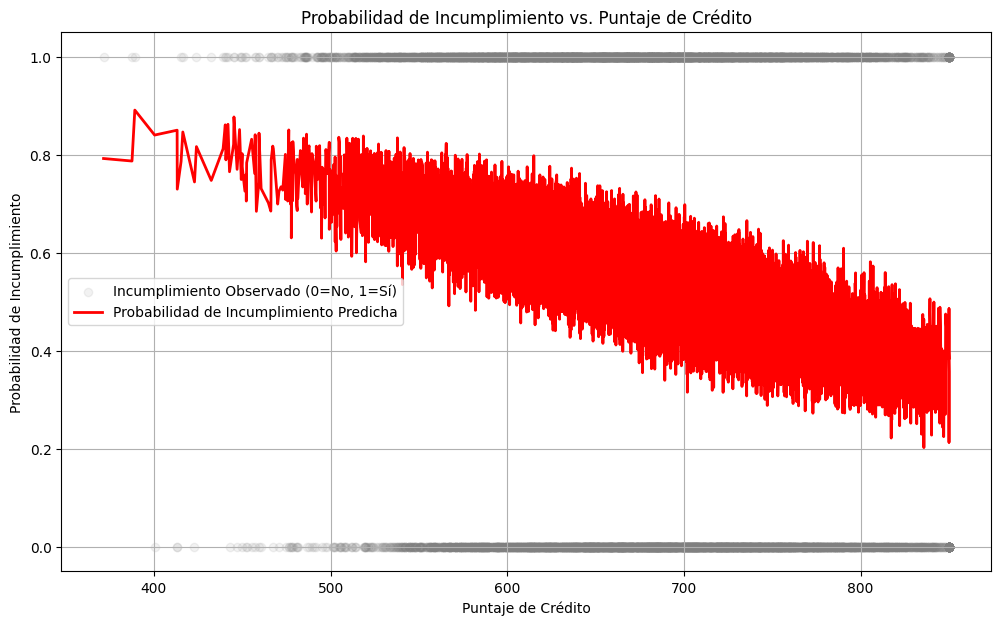

In [61]:
import matplotlib.pyplot as plt

# 1. Obtener las predicciones de probabilidad del modelo GLM
predicciones_probabilidad = modelo_glm.predict(X)

# 2. Elegir una variable independiente para la visualización, por ejemplo, 'puntaje_credito'
plt.figure(figsize=(12, 7))
plt.scatter(df_banca['puntaje_credito'], df_banca['default'],
            alpha=0.1, label='Incumplimiento Observado (0=No, 1=Sí)', color='gray')

# 3. Graficar la relación entre el puntaje de crédito y la probabilidad predicha
# Para una visualización más clara de la curva, podemos ordenar por puntaje de crédito
sorted_idx = np.argsort(df_banca['puntaje_credito'])
plt.plot(df_banca['puntaje_credito'].iloc[sorted_idx],
         predicciones_probabilidad.iloc[sorted_idx], color='red', linewidth=2,
         label='Probabilidad de Incumplimiento Predicha')

plt.title('Probabilidad de Incumplimiento vs. Puntaje de Crédito')
plt.xlabel('Puntaje de Crédito')
plt.ylabel('Probabilidad de Incumplimiento')
plt.legend()
plt.grid(True)
plt.show()

## Final Task
Resumir los resultados del modelo GLM aplicado al ejemplo sintético de banca, explicando la interpretación de los coeficientes y las implicaciones de la bondad de ajuste.

## Final Task
Resumir los resultados del modelo GLM aplicado al ejemplo sintético de banca, explicando la interpretación de los coeficientes y las implicaciones de la bondad de ajuste.

## Final Task
Resumir los resultados del modelo GLM aplicado al ejemplo sintético de banca, explicando la interpretación de los coeficientes y las implicaciones de la bondad de ajuste.

### Resumen del Modelo GLM para Incumplimiento de Préstamos

El modelo GLM de regresión logística ha sido ajustado con éxito para predecir la probabilidad de incumplimiento de un préstamo (`default`) basándose en la `edad`, `ingresos` y `puntaje_credito` de los clientes. A continuación, se interpreta el resumen del modelo:

#### Coeficientes del Modelo:

*   **const (Intercepto):** El coeficiente de la constante es `4.8100`. En una regresión logística, este valor representa el log-odds de incumplimiento cuando todas las variables independientes son cero. Es importante notar que la interpretación directa del intercepto es a menudo menos relevante que la de los coeficientes de las variables.

*   **edad:** El coeficiente para la `edad` es `-0.0189`. Esto significa que, manteniendo otras variables constantes, por cada año adicional de edad, el log-odds de incumplimiento disminuye en aproximadamente `0.0189`. Lo que se traduce en que las personas más jóvenes tienen una mayor probabilidad de incumplimiento, lo cual es consistente con el comportamiento de riesgo en el sector bancario.

*   **ingresos:** El coeficiente para los `ingresos` es `-8.598e-06` (aproximadamente -0.0000086). Esto indica que un aumento en los ingresos, manteniendo otras variables constantes, reduce marginalmente el log-odds de incumplimiento. Cuanto mayores son los ingresos, menor es la probabilidad de incumplimiento, lo cual es intuitivo.

*   **puntaje_credito:** El coeficiente para el `puntaje_credito` es `-0.0049`. Este es un coeficiente negativo significativo. Por cada punto adicional en el puntaje de crédito, el log-odds de incumplimiento disminuye en `0.0049`. Un mayor puntaje de crédito está fuertemente asociado con una menor probabilidad de incumplimiento, lo cual es una expectativa estándar en la evaluación crediticia.

Todos los p-valores (`P>|z|`) para los coeficientes son `0.000`, lo que indica que todas las variables (`edad`, `ingresos`, `puntaje_credito`) y la constante son estadísticamente significativas en la predicción de la probabilidad de incumplimiento a un nivel de confianza común (e.g., 95%).

#### Implicaciones de la Bondad de Ajuste:

*   **Log-Likelihood:** El valor de `Log-Likelihood` es `-6614.5`. Un log-likelihood más alto (menos negativo) indica un mejor ajuste del modelo a los datos.

*   **Deviance:** La `Deviance` es `13229.`. Este valor se utiliza para evaluar la bondad de ajuste del modelo, similar al RSS en la regresión lineal. Una deviance menor indica un mejor ajuste.

*   **Pearson chi2:** El valor de `Pearson chi2` es `1.00e+04`. Es otra medida de bondad de ajuste, comparando las frecuencias observadas con las esperadas.

*   **Pseudo R-squ. (CS):** El Pseudo R-cuadrado de Cox & Snell (`0.05392`) es una métrica que busca replicar el R-cuadrado de la regresión lineal en un contexto logístico. Un valor de `0.05392` sugiere que aproximadamente el 5.39% de la variabilidad en el incumplimiento es explicada por las variables del modelo. Aunque este valor puede parecer bajo en comparación con R-cuadrados de regresión lineal, es común en modelos logísticos, especialmente con datos sintéticos que pueden incluir un nivel de ruido considerable.

*   **No. Iterations:** El modelo convergió en `4` iteraciones, lo que es rápido e indica estabilidad en el proceso de ajuste.

#### Conclusión de la Visualización:

La gráfica de 'Probabilidad de Incumplimiento vs. Puntaje de Crédito' muestra claramente cómo a medida que el puntaje de crédito aumenta, la probabilidad predicha de incumplimiento disminuye. Aunque hay dispersión en los datos observados (los puntos grises), la línea roja de predicción del modelo captura la tendencia general, demostrando la relación inversa esperada y la capacidad del modelo para estimar estas probabilidades.

## Final Task

### Subtask:
Resumir los resultados del modelo GLM aplicado al ejemplo sintético de banca, explicando la interpretación de los coeficientes y las implicaciones de la bondad de ajuste.


## Summary:

### Data Analysis Key Findings

*   **Synthetic Data Generation**: A synthetic banking dataset of 10,000 observations was successfully generated. This dataset includes `edad` (age), `ingresos` (income), `puntaje_credito` (credit score), and a binary `default` variable. The generation process incorporated an inverse relationship between these variables and the probability of default (e.g., higher age, higher income, and higher credit score were set to reduce default probability).
*   **Model Fitting**: A Generalized Linear Model (GLM) using a Binomial family and Logit link function (logistic regression) was successfully fitted to predict loan default.
*   **Statistical Significance of Predictors**: All independent variables (`edad`, `ingresos`, `puntaje_credito`) and the constant term were found to be statistically significant (p-values < 0.001) in predicting the probability of default.
*   **Coefficient Interpretation**:
    *   **Edad (Age)**: The coefficient of -0.0189 indicates that for each additional year of age, the log-odds of default decrease by approximately 0.0189, suggesting older individuals have a lower probability of default.
    *   **Ingresos (Income)**: The coefficient of -8.598e-06 shows that higher income is associated with a marginal reduction in the log-odds of default.
    *   **Puntaje de Crédito (Credit Score)**: The coefficient of -0.0049 implies that for every point increase in credit score, the log-odds of default decrease by 0.0049, confirming a strong inverse relationship between credit score and default probability.
*   **Goodness of Fit**: The Pseudo R-squared (Cox & Snell) value of 0.05392 indicates that approximately 5.39% of the variability in loan default is explained by the model's predictors. While this value might seem low, it is common for logistic regression models, especially with synthetic data that includes inherent noise. The model converged quickly in 4 iterations, suggesting stability.
*   **Prediction Visualization**: A visualization confirmed that the model effectively captures the inverse relationship between credit score and the predicted probability of default, showing a decreasing probability curve as credit scores increase.

### Insights or Next Steps

*   The GLM successfully identifies age, income, and credit score as significant predictors of loan default, with relationships consistent with financial intuition (e.g., higher credit score, lower default probability). This model can serve as a foundational tool for initial risk assessment.
*   For further analysis, the model's performance could be rigorously evaluated using additional metrics such as ROC curves, AUC score, precision, recall, and F1-score to assess its predictive power and classification accuracy in a real-world context.
